In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
import nasdaqdatalink

In [6]:
nasdaqdatalink.ApiConfig.api_key = ''

In [7]:
df = nasdaqdatalink.get_table(
    datatable_code='WIKI/PRICES', 
    ticker='TSLA', 
    paginate=True,)

In [8]:
print(df.head(), \
      df.shape, \
      df.tail(), \
      df.columns)

     ticker       date    open    high     low   close      volume  \
None                                                                 
0      TSLA 2018-03-27  304.00  304.27  277.18  279.18  13696168.0   
1      TSLA 2018-03-26  307.34  307.59  291.36  304.18   8324639.0   
2      TSLA 2018-03-23  311.25  311.61  300.45  301.54   6600538.0   
3      TSLA 2018-03-22  313.89  318.82  308.18  309.10   4914307.0   
4      TSLA 2018-03-21  310.25  322.44  310.19  316.53   5927881.0   

      ex-dividend  split_ratio  adj_open  adj_high  adj_low  adj_close  \
None                                                                     
0             0.0          1.0    304.00    304.27   277.18     279.18   
1             0.0          1.0    307.34    307.59   291.36     304.18   
2             0.0          1.0    311.25    311.61   300.45     301.54   
3             0.0          1.0    313.89    318.82   308.18     309.10   
4             0.0          1.0    310.25    322.44   310.19     3

In [9]:
df["date"] = pd.to_datetime(df["date"])

In [10]:
df = df.sort_values("date")

In [11]:
prices = df["adj_close"]

In [12]:
volume = df["adj_volume"]

In [13]:
df.head()

,ticker,date,open,high,low,close,volume,ex-dividend,split_ratio,adj_open,adj_high,adj_low,adj_close,adj_volume
None,,,,,,,,,,,,,,
1948,TSLA,2010-06-29,19.00,25.0000,17.54,23.89,18766300.0,0.0,1.0,19.00,25.0000,17.54,23.89,18766300.0
1947,TSLA,2010-06-30,25.79,30.4192,23.30,23.83,17187100.0,0.0,1.0,25.79,30.4192,23.30,23.83,17187100.0
1946,TSLA,2010-07-01,25.00,25.9200,20.27,21.96,8218800.0,0.0,1.0,25.00,25.9200,20.27,21.96,8218800.0
1945,TSLA,2010-07-02,23.00,23.1000,18.71,19.20,5139800.0,0.0,1.0,23.00,23.1000,18.71,19.20,5139800.0
1944,TSLA,2010-07-06,20.00,20.0000,15.83,16.11,6866900.0,0.0,1.0,20.00,20.0000,15.83,16.11,6866900.0


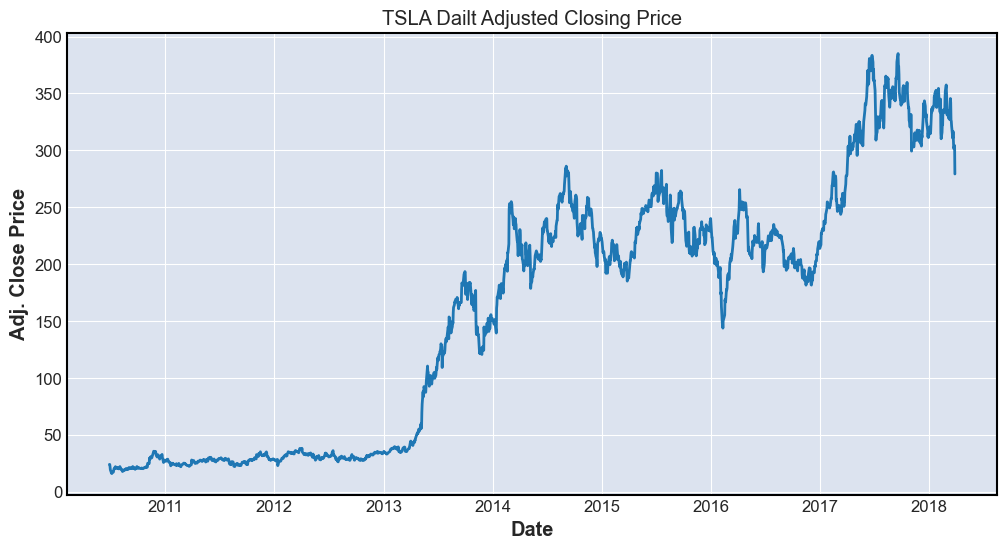

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(df['date'], prices)

plt.title("TSLA Dailt Adjusted Closing Price")
plt.xlabel("Date")
plt.ylabel("Adj. Close Price")

plt.grid(True)
plt.show()

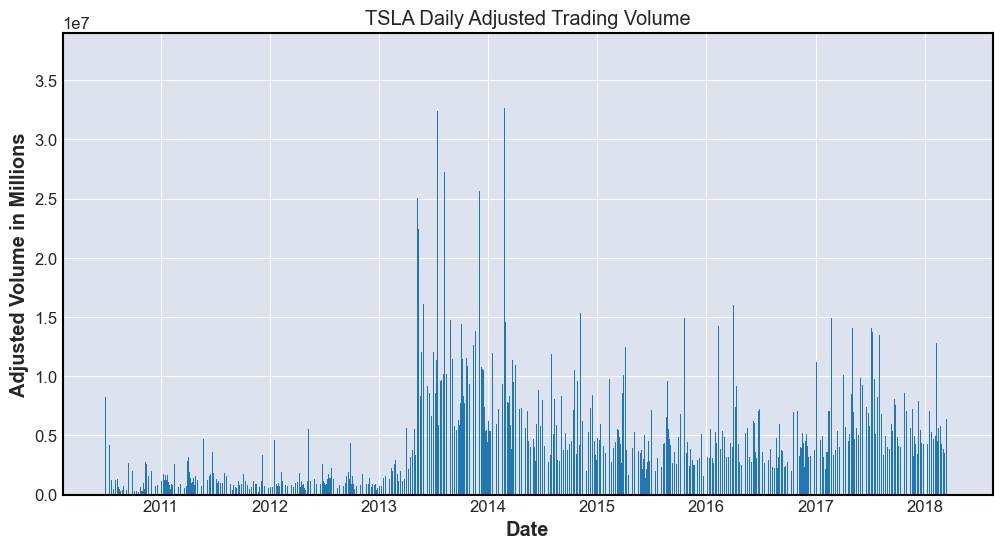

In [27]:
plt.figure(figsize=(12, 6))
plt.bar(df['date'], volume)
plt.title("TSLA Daily Adjusted Trading Volume")
plt.xlabel("Date")
plt.ylabel("Adjusted Volume in Millions")
plt.show()

In [38]:
import mplfinance as mpf

In [48]:
df_candle = nasdaqdatalink.get_table(
    datatable_code="WIKI/PRICES",
    ticker="TSLA",
    date={"gte": "2017-12-01", "lte": "2018-03-21"},
    qopts={"columns": ["date", "open", "high", "low", "close", "volume"]},
    api_key=nasdaqdatalink.ApiConfig.api_key)

df_candle.head()

,date,open,high,low,close,volume
None,,,,,,
0,2018-03-21,310.25,322.44,310.19,316.53,5927881.0
1,2018-03-20,314.87,316.25,308.76,310.55,4726182.0
2,2018-03-19,316.50,320.75,309.67,313.56,7440766.0
3,2018-03-16,325.96,327.40,319.07,321.35,6058612.0
4,2018-03-15,329.38,332.85,321.10,325.60,6366922.0


In [49]:
df_candle['date'] = pd.to_datetime(df_candle['date'])

In [50]:
df_candle = df_candle.sort_values('date')

In [51]:
df_candle = df_candle.set_index('date')

In [52]:
df_candle = df_candle.rename(columns={"open": "Open",
                                      "high": "High",
                                      "low": "Low",
                                      "close": "Close",
                                      "volume": "Volume"})

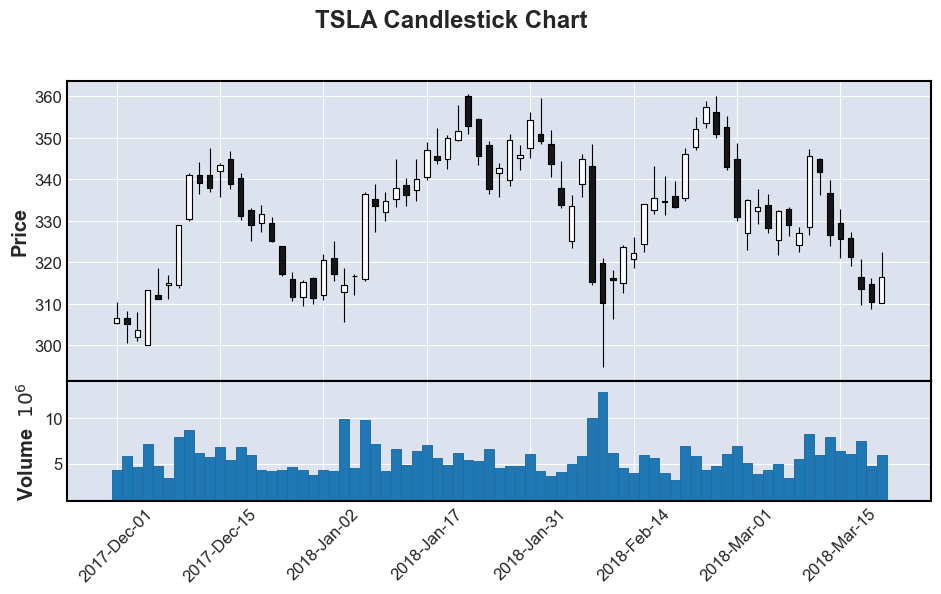

In [53]:
mpf.plot(df_candle,
         type="candle",
         volume=True,
         title="TSLA Candlestick Chart",
         ylabel="Price",
         figsize=(12, 6))

In [66]:
daily_returns = prices.pct_change()

daily_returns.head()

None
1948         NaN
1947   -0.002512
1946   -0.078473
1945   -0.125683
1944   -0.160937
Name: adj_close, dtype: float64

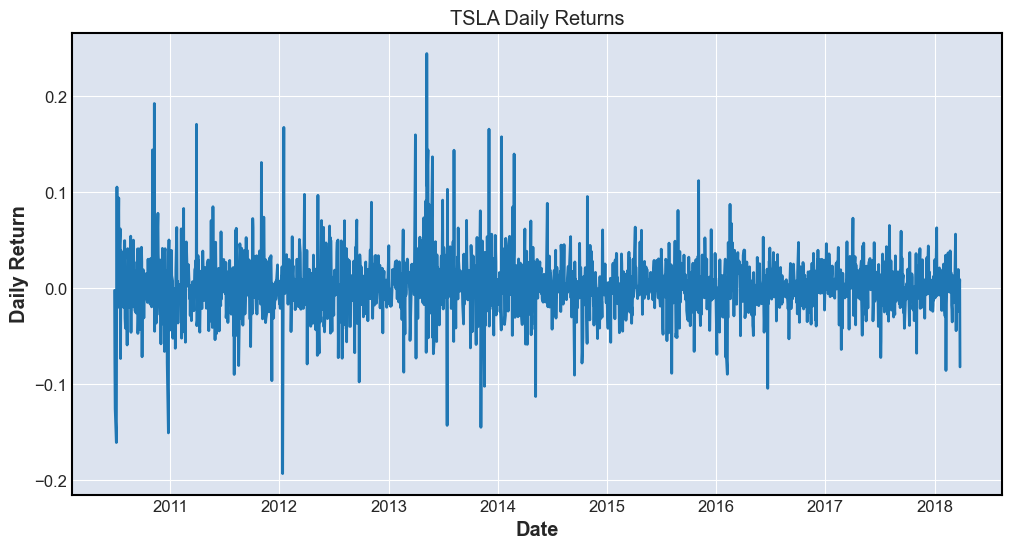

In [68]:
plt.figure(figsize=(12, 6))

plt.plot(df['date'], daily_returns)

plt.title("TSLA Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.grid(True)
plt.show()

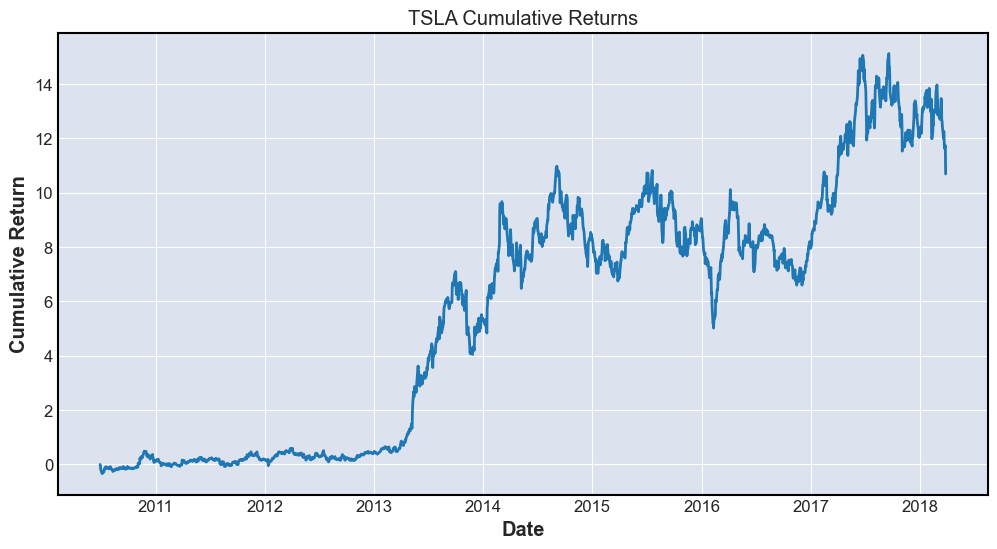

In [69]:
cumulative_returns = (1 + daily_returns).cumprod() - 1
plt.figure(figsize=(12, 6))
plt.plot(df['date'], cumulative_returns)
plt.title("TSLA Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()

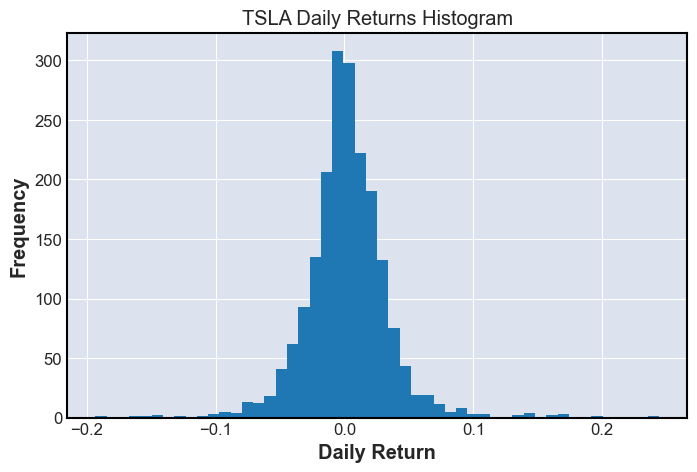

In [70]:
plt.figure(figsize=(8, 5))
daily_returns.hist(bins=50)
plt.title("TSLA Daily Returns Histogram")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

In [71]:
daily_returns.describe()

count    1948.000000
mean        0.001766
std         0.031849
min        -0.193274
25%        -0.013980
50%         0.000828
75%         0.017712
max         0.244029
Name: adj_close, dtype: float64

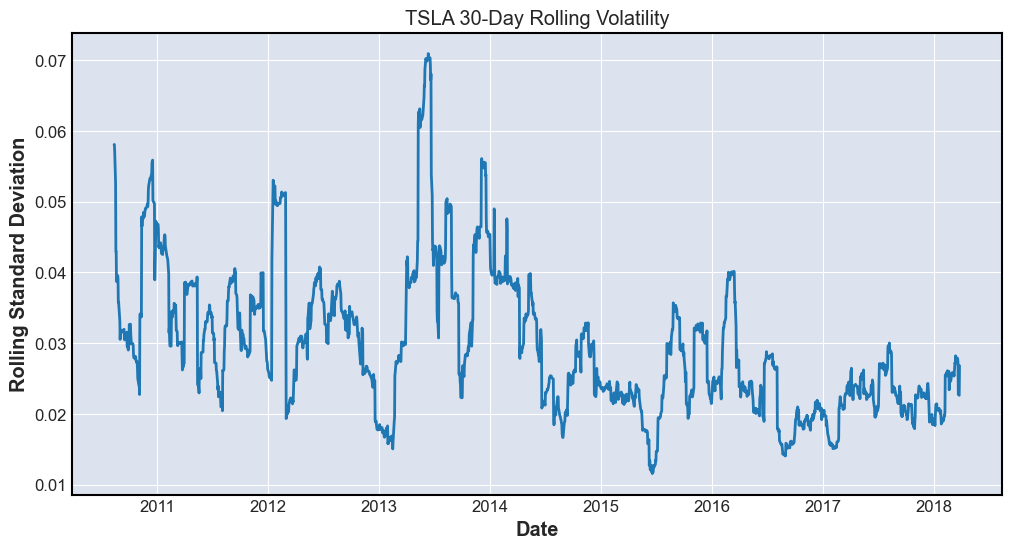

In [73]:
rolling_volatility = daily_returns.rolling(window=30).std()
plt.figure(figsize=(12, 6))
plt.plot(df['date'], rolling_volatility)
plt.title("TSLA 30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Rolling Standard Deviation")
plt.grid(True)
plt.show()

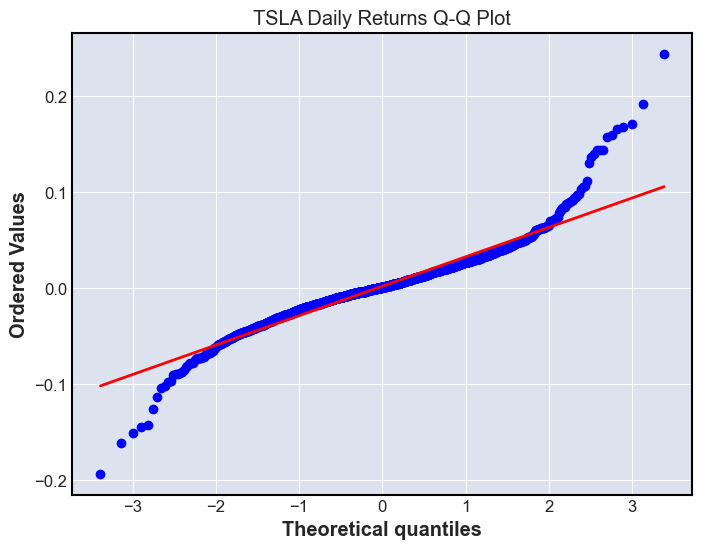

In [74]:
from scipy import stats
returns_clean = daily_returns.dropna()
fig, ax = plt.subplots(figsize=(8, 6))
stats.probplot(returns_clean, dist="norm", plot=ax)
ax.set_title("TSLA Daily Returns Q-Q Plot")
plt.show()

In [75]:
df_multi = nasdaqdatalink.get_table(datatable_code="Wiki/Prices",
                                    ticker=["tsla", "AaPL", "MSFT"],
                                    date={"gte": "2017-12-01", "lte":"2018-03-27"},
                                    qopts={"columns": ["ticker", "date", "adj_close"]},
                                    paginate=True,
                                    api_key=nasdaqdatalink.ApiConfig.api_key)

In [76]:
import time

In [77]:
tickers = ["TSLA", "AAPPL", "MSFT"]

In [78]:
all_data = []

In [180]:
for tickers in tickers:
    print("Downloading:", tickers)

    time.sleep(3)
    temp_df = nasdaqdatalink.get_table(datatable_code="WIKI/PRICES",
                                       ticker=tickers,
                                       date={"gte": "2017-12-01", "lte":"2018-03-27"},
                                       qopts={"columns": ["ticker", "date", "adj_close"]},
                                       paginate=True,
                                       api_key=nasdaqdatalink.ApiConfig.api_key)

    all_data.append(temp_df)

    

Downloading: T


LimitExceededError: (Status 429) (Nasdaq Data Link Error QELx06) You have exceeded the API speed limit and your account has temporarily been disabled.  Please contact clientsuccess@nasdaq.com for more information.

In [181]:
tickers = ["TSLA", "AAPL", "MSFT"]

all_data = []

for ticker in tickers:
    
    print("Downloading:", ticker)
    
    temp_df = nasdaqdatalink.get_table(
        datatable_code="WIKI/PRICES",
        ticker=ticker,
        date={"gte": "2018-03-01", "lte": "2018-03-09"},
        qopts={"columns": ["ticker", "date", "adj_close"]},
        api_key=nasdaqdatalink.ApiConfig.api_key
    )
    
    all_data.append(temp_df)

df_multi = pd.concat(all_data)

df_multi.head()

Downloading: TSLA


LimitExceededError: (Status 429) (Nasdaq Data Link Error QELx06) You have exceeded the API speed limit and your account has temporarily been disabled.  Please contact clientsuccess@nasdaq.com for more information.

In [182]:
df_tsla = nasdaqdatalink.get_table(
    datatable_code="WIKI/PRICES",
    ticker="TSLA",
    date={"gte": "2018-03-01", "lte": "2018-03-27"},
    qopts={"columns": ["ticker", "date", "adj_close"]},
    api_key=nasdaqdatalink.ApiConfig.api_key
)

df_tsla.head()

LimitExceededError: (Status 429) (Nasdaq Data Link Error QELx06) You have exceeded the API speed limit and your account has temporarily been disabled.  Please contact clientsuccess@nasdaq.com for more information.

In [184]:
df_tsla = nasdaqdatalink.get_table(
        datatable_code="WIKI/PRICES",
        ticker="TSLA",
        paginate=True,
        api_key=nasdaqdatalink.ApiConfig.api_key)

df_tsla.head()

LimitExceededError: (Status 429) (Nasdaq Data Link Error QELx06) You have exceeded the API speed limit and your account has temporarily been disabled.  Please contact clientsuccess@nasdaq.com for more information.

In [185]:
df_tsla = nasdaqdatalink.get_table(
    "WIKI/PRICES",
    qopts={"columns": ["ticker", "date", "adj_close"]},
    ticker="TSLA",
    date={"gte": "2018-03-01", "lte": "2018-03-05"},
    api_key=nasdaqdatalink.ApiConfig.api_key)

df_tsla.head()

LimitExceededError: (Status 429) (Nasdaq Data Link Error QELx06) You have exceeded the API speed limit and your account has temporarily been disabled.  Please contact clientsuccess@nasdaq.com for more information.

In [199]:
import nasdaqdatalink

df_tsla = nasdaqdatalink.get_table(datatable_code="WIKI/PRICES",
                                   ticker='TSLA',
                                   date="2018-03-01",
                                   api_key=nasdaqdatalink.ApiConfig.api_key)

df_tsla.head()

,ticker,date,open,high,low,close,volume,ex-dividend,split_ratio,adj_open,adj_high,adj_low,adj_close,adj_volume
None,,,,,,,,,,,,,,
0,TSLA,2018-03-01,345.01,348.67,330.07,330.93,6885601.0,0.0,1.0,345.01,348.67,330.07,330.93,6885601.0


In [1]:
df_tsla = nasdaqdatalink.get_table(datatable_code="WIKI/PRICES",
                                   ticker="TSLA",
                                   date={"gte": "2018-03-01", "lte": "2018-03-27"},
                                   api_key=nasdaqdatalink.ApiConfig.api_key)

df_tsla.head()

NameError: name 'nasdaqdatalink' is not defined

In [83]:
df_tsla = nasdaqdatalink.get_table(datatable_code="WIKI/PRICES",
                                   ticker='TSLA',
                                   date={"gte": "2018-03-01", "lte": "2018-03-20"},
                                   qopts={"columns": ["ticker", "date", "adj_close"]},
                                   api_key=nasdaqdatalink.ApiConfig.api_key)

df_tsla.head()

,ticker,date,adj_close
None,,,
0,TSLA,2018-03-20,310.55
1,TSLA,2018-03-19,313.56
2,TSLA,2018-03-16,321.35
3,TSLA,2018-03-15,325.60
4,TSLA,2018-03-14,326.63


In [84]:
df_aapl = nasdaqdatalink.get_table(datatable_code="WIKI/PRICES",
                                   ticker="AAPL",
                                   date={"gte": "2018-03-01", "lte": "2018-03-20"},
                                   qopts={"columns": ["ticker", "date", "adj_close"]},
                                   api_key=nasdaqdatalink.ApiConfig.api_key)
df_aapl.head()

,ticker,date,adj_close
None,,,
0,AAPL,2018-03-20,175.24
1,AAPL,2018-03-19,175.30
2,AAPL,2018-03-16,178.02
3,AAPL,2018-03-15,178.65
4,AAPL,2018-03-14,178.44


In [85]:
df_msft = nasdaqdatalink.get_table(datatable_code="WIKI/PRICES",
                                   ticker="MSFT",
                                   date={"gte": "2018-03-01", "lte": "2018-03-20"},
                                   qopts={"columns": ["ticker", "date", "adj_close"]},
                                   api_key=nasdaqdatalink.ApiConfig.api_key)
df_msft.head()

,ticker,date,adj_close
None,,,
0,MSFT,2018-03-20,93.13
1,MSFT,2018-03-19,92.89
2,MSFT,2018-03-16,94.60
3,MSFT,2018-03-15,94.18
4,MSFT,2018-03-14,93.85


In [86]:
df_multi = pd.concat([df_tsla, df_aapl, df_msft])

In [215]:
df_multi.head()

,ticker,date,adj_close
None,,,
0,TSLA,2018-03-09,327.17
1,TSLA,2018-03-08,329.10
2,TSLA,2018-03-07,332.30
3,TSLA,2018-03-06,328.20
4,TSLA,2018-03-05,333.35


In [216]:
df_multi.tail()

,ticker,date,adj_close
None,,,
2,MSFT,2018-03-07,93.86
3,MSFT,2018-03-06,93.32
4,MSFT,2018-03-05,93.64
5,MSFT,2018-03-02,93.05
6,MSFT,2018-03-01,92.85


In [87]:
df_multi["date"] = pd.to_datetime(df_multi["date"])

In [88]:
df_multi = df_multi.sort_values(["ticker", "date"])

In [219]:
df_multi.head()

,ticker,date,adj_close
None,,,
6,AAPL,2018-03-01,175.00
5,AAPL,2018-03-02,176.21
4,AAPL,2018-03-05,176.82
3,AAPL,2018-03-06,176.67
2,AAPL,2018-03-07,175.03


In [89]:
price_table = df_multi.pivot(index="date",
                             columns="ticker",
                             values="adj_close")

In [90]:
price_table.head()

ticker,AAPL,MSFT,TSLA
date,,,
2018-03-01,175.00,92.85,330.93
2018-03-02,176.21,93.05,335.12
2018-03-05,176.82,93.64,333.35
2018-03-06,176.67,93.32,328.20
2018-03-07,175.03,93.86,332.30


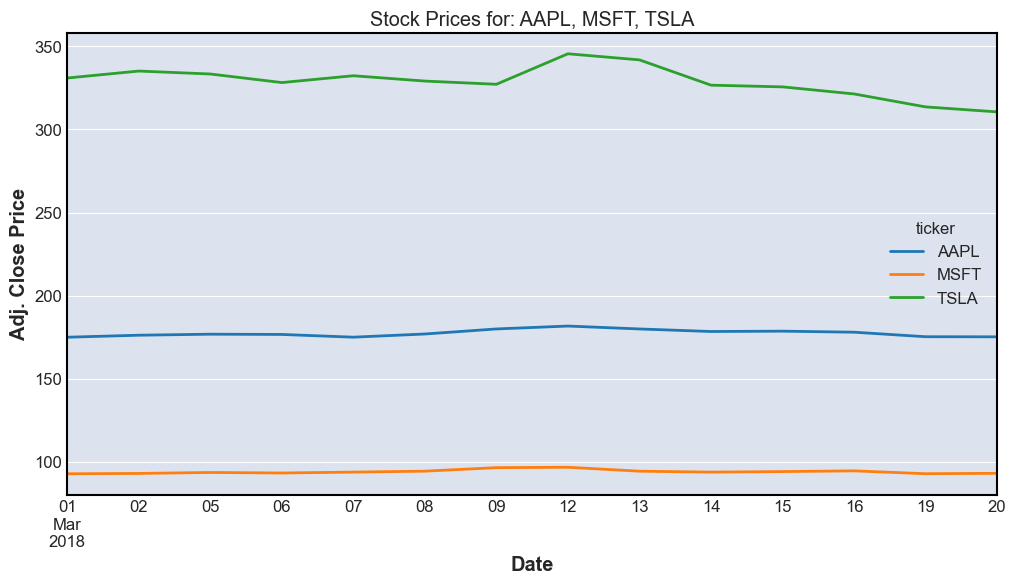

In [91]:
price_table.plot(figsize=(12, 6))

plt.title("Stock Prices for: AAPL, MSFT, TSLA")
plt.xlabel("Date")
plt.ylabel("Adj. Close Price")
plt.grid(True)
plt.show()

In [92]:
multi_returns = price_table.pct_change()

In [93]:
correlation_matrix = multi_returns.corr()

In [94]:
correlation_matrix

ticker,AAPL,MSFT,TSLA
ticker,,,
AAPL,1.000000,0.765113,0.457812
MSFT,0.765113,1.000000,0.290880
TSLA,0.457812,0.290880,1.000000


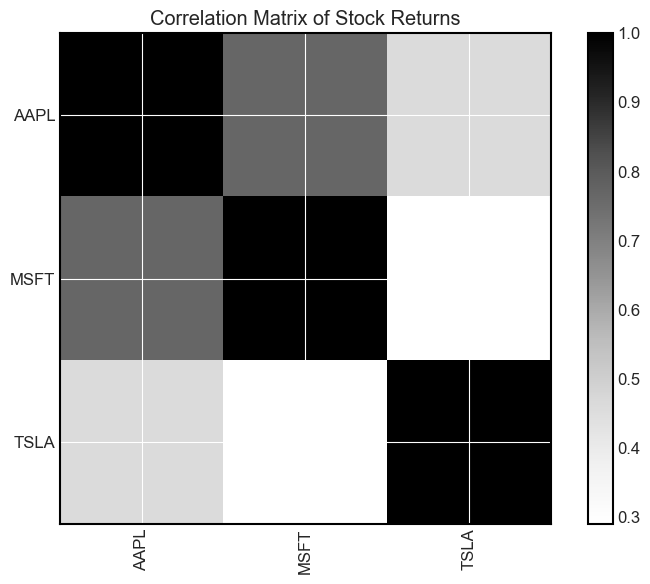

In [95]:
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix)
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns,
           rotation=90)
plt.yticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns)
plt.title("Correlation Matrix of Stock Returns")
plt.tight_layout()

In [96]:
tsla_prices = price_table["TSLA"]
tsla_prices.head()

date
2018-03-01    330.93
2018-03-02    335.12
2018-03-05    333.35
2018-03-06    328.20
2018-03-07    332.30
Name: TSLA, dtype: float64

In [97]:
sma_short = tsla_prices.rolling(window=3).mean()

In [98]:
sma_long = tsla_prices.rolling(window=4).mean()

In [99]:
df_sma = pd.DataFrame({"TSLA Price": tsla_prices,
                       "3-Day SMA": sma_short,
                       "4-Day SMA": sma_long})

In [100]:
df_sma.head()

,TSLA Price,3-Day SMA,4-Day SMA
date,,,
2018-03-01,330.93,NaN,NaN
2018-03-02,335.12,NaN,NaN
2018-03-05,333.35,333.133333,NaN
2018-03-06,328.20,332.223333,331.9000
2018-03-07,332.30,331.283333,332.2425


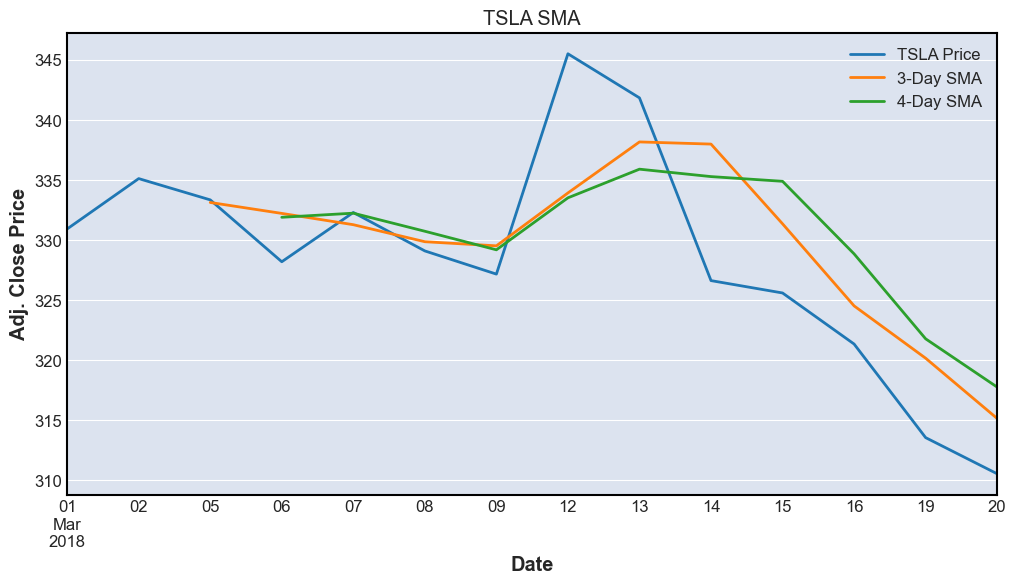

In [101]:
df_sma.plot(figsize=(12, 6))
plt.title("TSLA SMA")
plt.xlabel("Date")
plt.ylabel("Adj. Close Price")
plt.grid(True)

In [102]:
short_ema = tsla_prices.ewm(span=3, adjust=False).mean()

In [103]:
long_ema = tsla_prices.ewm(span=4, adjust=False).mean()

In [104]:
df_ema = pd.DataFrame({"TSLA Price": tsla_prices,
                       "3-Day EMA": short_ema,
                       "4-Day EMA": long_ema})

In [105]:
df_ema.head()

,TSLA Price,3-Day EMA,4-Day EMA
date,,,
2018-03-01,330.93,330.930000,330.930000
2018-03-02,335.12,333.025000,332.606000
2018-03-05,333.35,333.187500,332.903600
2018-03-06,328.20,330.693750,331.022160
2018-03-07,332.30,331.496875,331.533296


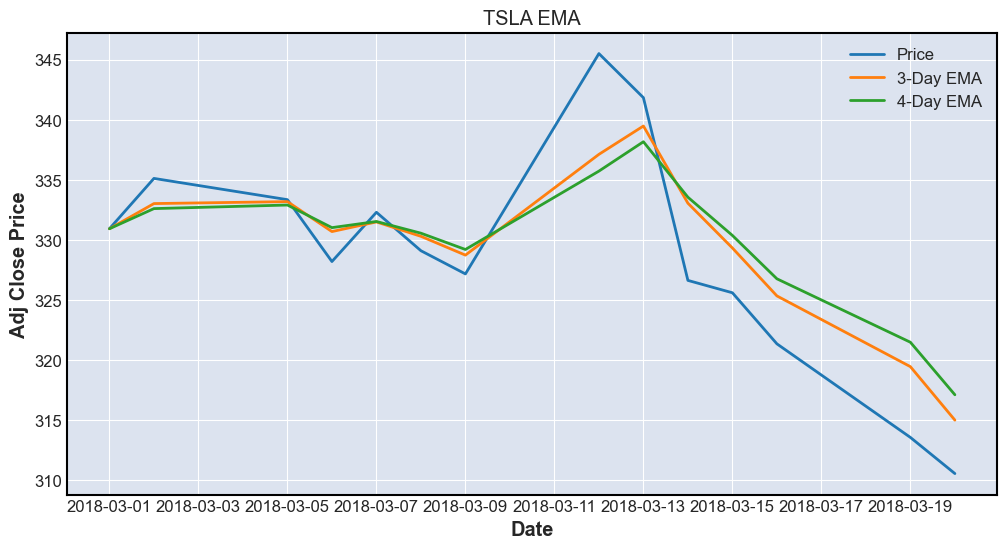

In [106]:
plt.figure(figsize=(12, 6))
plt.plot(df_ema["TSLA Price"], label="Price")
plt.plot(df_ema["3-Day EMA"], label="3-Day EMA")
plt.plot(df_ema["4-Day EMA"], label="4-Day EMA")
plt.title("TSLA EMA")
plt.xlabel("Date")
plt.ylabel("Adj Close Price")
plt.legend()
plt.grid(True)